In [1]:
# STEP 1: Load the external knowledgebase and convert into pages.
# Example - Knowledgebase in pdf format
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("Artificial-Intelligence.pdf")
pdf_pages = loader.load()
print(f'No of pages: {len(pdf_pages)}')

c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


No of pages: 80


In [2]:
# STEP 2: Split pages into chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Spilit pages into small chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ",", " "]
)
split_docs = splitter.split_documents(pdf_pages)
print(f'Total no of chunks {len(split_docs)}')

Total no of chunks 344


In [3]:
# STEP 3: Create vector embeddings using FAISS

from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS

embedding_model = OllamaEmbeddings(model="nomic-embed-text")
vector_store = FAISS.from_documents(split_docs, embedding=embedding_model)
vector_store.save_local("faiss_python_book")
print('python book vector store is created using FAISS...')



python book vector store is created using FAISS...


In [4]:
# STEP 4: Build Retrieval Chain

from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import RetrievalQA
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print("Model is ready")

USER_PROMPT_TEMPLATE = """Use the following pieces of the context to answer user's question.
If you don't know the answer, just say you don't know, don't try to make up the answer.
------------------------
{context}
Question: {question}
"""

USER_PROMPT = PromptTemplate(
    template=USER_PROMPT_TEMPLATE,
    input_variables=["context", "question"]
)
retriever = vector_store.as_retriever()
qa_chain = RetrievalQA.from_chain_type(
    model,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True,
    chain_type_kwargs={"prompt": USER_PROMPT}
)
print(qa_chain)
print('Retrieval chain is built successfully...')

Model is ready
verbose=False combine_documents_chain=StuffDocumentsChain(verbose=False, llm_chain=LLMChain(verbose=False, prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="Use the following pieces of the context to answer user's question.\nIf you don't know the answer, just say you don't know, don't try to make up the answer.\n------------------------\n{context}\nQuestion: {question}\n"), llm=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.0'}}, output_version=None, model='gpt-oss:120b-cloud'), output_parser=StrOutputParser(), llm_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_variable_name='context') return_source_documents=True retriever=VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000286D2F27410>, search

In [5]:
# STEP 1 - Define the central state of the application
from typing import Annotated, TypedDict
from typing import List
from langchain_core.documents import Document

class RAGState(TypedDict):
    question: str
    documents: List[Document]
    answer: str

print('RAG Graph State is ready')


RAG Graph State is ready


In [6]:
# STEP 2 - Define Nodes
def retrieve_documents_node(state:RAGState):
    question = state['question']
    documents = retriever.invoke(question)
    return {
        "documents": documents
    }

def generate_answer_node(state:RAGState):
    question = state['question']
    documents = state['documents']

    context = "\n\n".join(
        document.page_content for document in documents
    )
    messages = USER_PROMPT.invoke({
        "context": context,
        "question": question
    })
    response = model.invoke(messages)
    return {
        "answer": response.content
    }

print('RAG nodes are ready')

RAG nodes are ready


RAG graph is ready


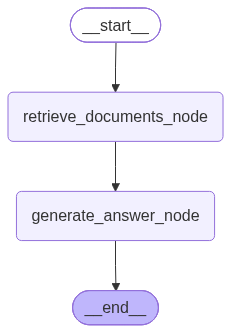

In [7]:
# STEP 3 - Bind nodes together using Edges
from langgraph.graph import StateGraph, START, END

rag_graph_builder = StateGraph(RAGState)

# Node registration
rag_graph_builder.add_node("retrieve_documents_node", retrieve_documents_node)
rag_graph_builder.add_node("generate_answer_node", generate_answer_node)

# Add edges to nodes
rag_graph_builder.add_edge(START, "retrieve_documents_node")
rag_graph_builder.add_edge("retrieve_documents_node", "generate_answer_node")
rag_graph_builder.add_edge("generate_answer_node", END)

rag_graph = rag_graph_builder.compile()
print('RAG graph is ready')
rag_graph

In [9]:
response = rag_graph.invoke({
    "question": "What is an Artificial Intelligence?"
})

response

{'question': 'What is an Artificial Intelligence?',
 'documents': [Document(id='4d6e4b92-9eac-4304-807a-e144ccc6e965', metadata={'producer': 'Pdftools SDK', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2024-09-19T22:02:58+00:00', 'source': 'Artificial-Intelligence.pdf', 'total_pages': 80, 'page': 0, 'page_label': '1'}, page_content='ARTIFICIAL \nINTELLIGENCE'),
  Document(id='9826b322-a2b9-4a7d-b5ee-c4f0e5353c02', metadata={'producer': 'Pdftools SDK', 'creator': 'PyPDF', 'creationdate': '', 'moddate': '2024-09-19T22:02:58+00:00', 'source': 'Artificial-Intelligence.pdf', 'total_pages': 80, 'page': 7, 'page_label': '8'}, page_content='copy of something natural.\nARTIFICIAL INTELLIGENCE \nThe theory and development of \ncomputer systems able to per-\nform tasks that normally require \nhuman intelligence.\nAUTOMATION The technique, \nmethod, or system of controlling \na process by reducing human \nintervention to a minimum.'),
  Document(id='f509e659-56c1-48fb-8984-95de24cfb499', me